# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

## Due: Midnight on March 30 (with 2-hour grace period) and worth 25 points





### What We Will Do in This Milestone Assignment

1. You will convene your team (listed on Blackboard) and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. The team leader should upload the notebook and then create a group on GS for the group submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [43]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
import kagglehub
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [41]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


-Objective: To accurately and efficetive predict the assessed tax value of any house on Zillow based on the features and offerings the house has to offer.

-Solution: Having an accurate assessment of a tax value can help future homeowners understand the economic expectations to buy a home and better prepare for the financial costs, help price the property more fairly, understand how certain features infuluence this rate (help make it more afforable or learn to prioritize needs), help individuals, ensure potential buyers are getting a fair rate (compared to other similar properties) - helps leverage offers.

-Success/Failure: Test/train model? If our values are within close range of actual assessed values in 2017 homes.?

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [42]:
df = pd.read_csv("/Users/ez873/Documents/Module-3-Assignments-main/zillow_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ez873/Documents/Module-3-Assignments-main/zillow_dataset.csv'

In [44]:
df = pd.read_csv("zillow_dataset.csv")

In [45]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [47]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Of the 55 total variables, 22 are categorical. Five are loaded in as objects: hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, and taxdelinquencyflag. The remaining 17 are float64 class features but are numerical IDs capturing a fixed set of categories, and as such are also categorical. Those variables are airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, decktypeid, fips, heatingorsystemtypeid, pooltypeid10, pooltypeid2, pooltypeid7, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzipm storytypeid, and typeconstructiontypeid. Three additional variables could be considered either categorical or continuous depending on what type of analysis they may be used for: assessmentyear, unitcnt, and numberofstories.  

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Variables like what type of pool, whether or not there is a hot tub, and the type of deck all have one unique value and are unlikely to contribute meaningfully to the value of a house (I think...?). There are also many different location-related variables. While location is essential when thinking about home value, there are likely to be collinearities that can be minimized with feature selection to best suit the business purpose and method at hand.  


**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

There are several variables with few non-null values. Since there are 77,613 IDs, we can be confident that most variables with less than 1000 non-null values are unlikely to provide useful predictive information. Examples include architecturalstyletypeid (207 non-null), basementsqft (50), buildingclasstypeid (15), decktypeid (614), finishedsquarefeet13 (42), etc.. 

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

In contrast, some variables have so many unique values that they are unlikely to provide useful information. For example, the latitude and longitude variables have 64038 and 62461 unique values respectively. They cannot be interpreted as true numerics, should only really be used in combination (to identify a location), and outnumber the target for unique values. Latitude and longitude are not likely to be useful unless we pursue some type of geospatial analysis.  

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

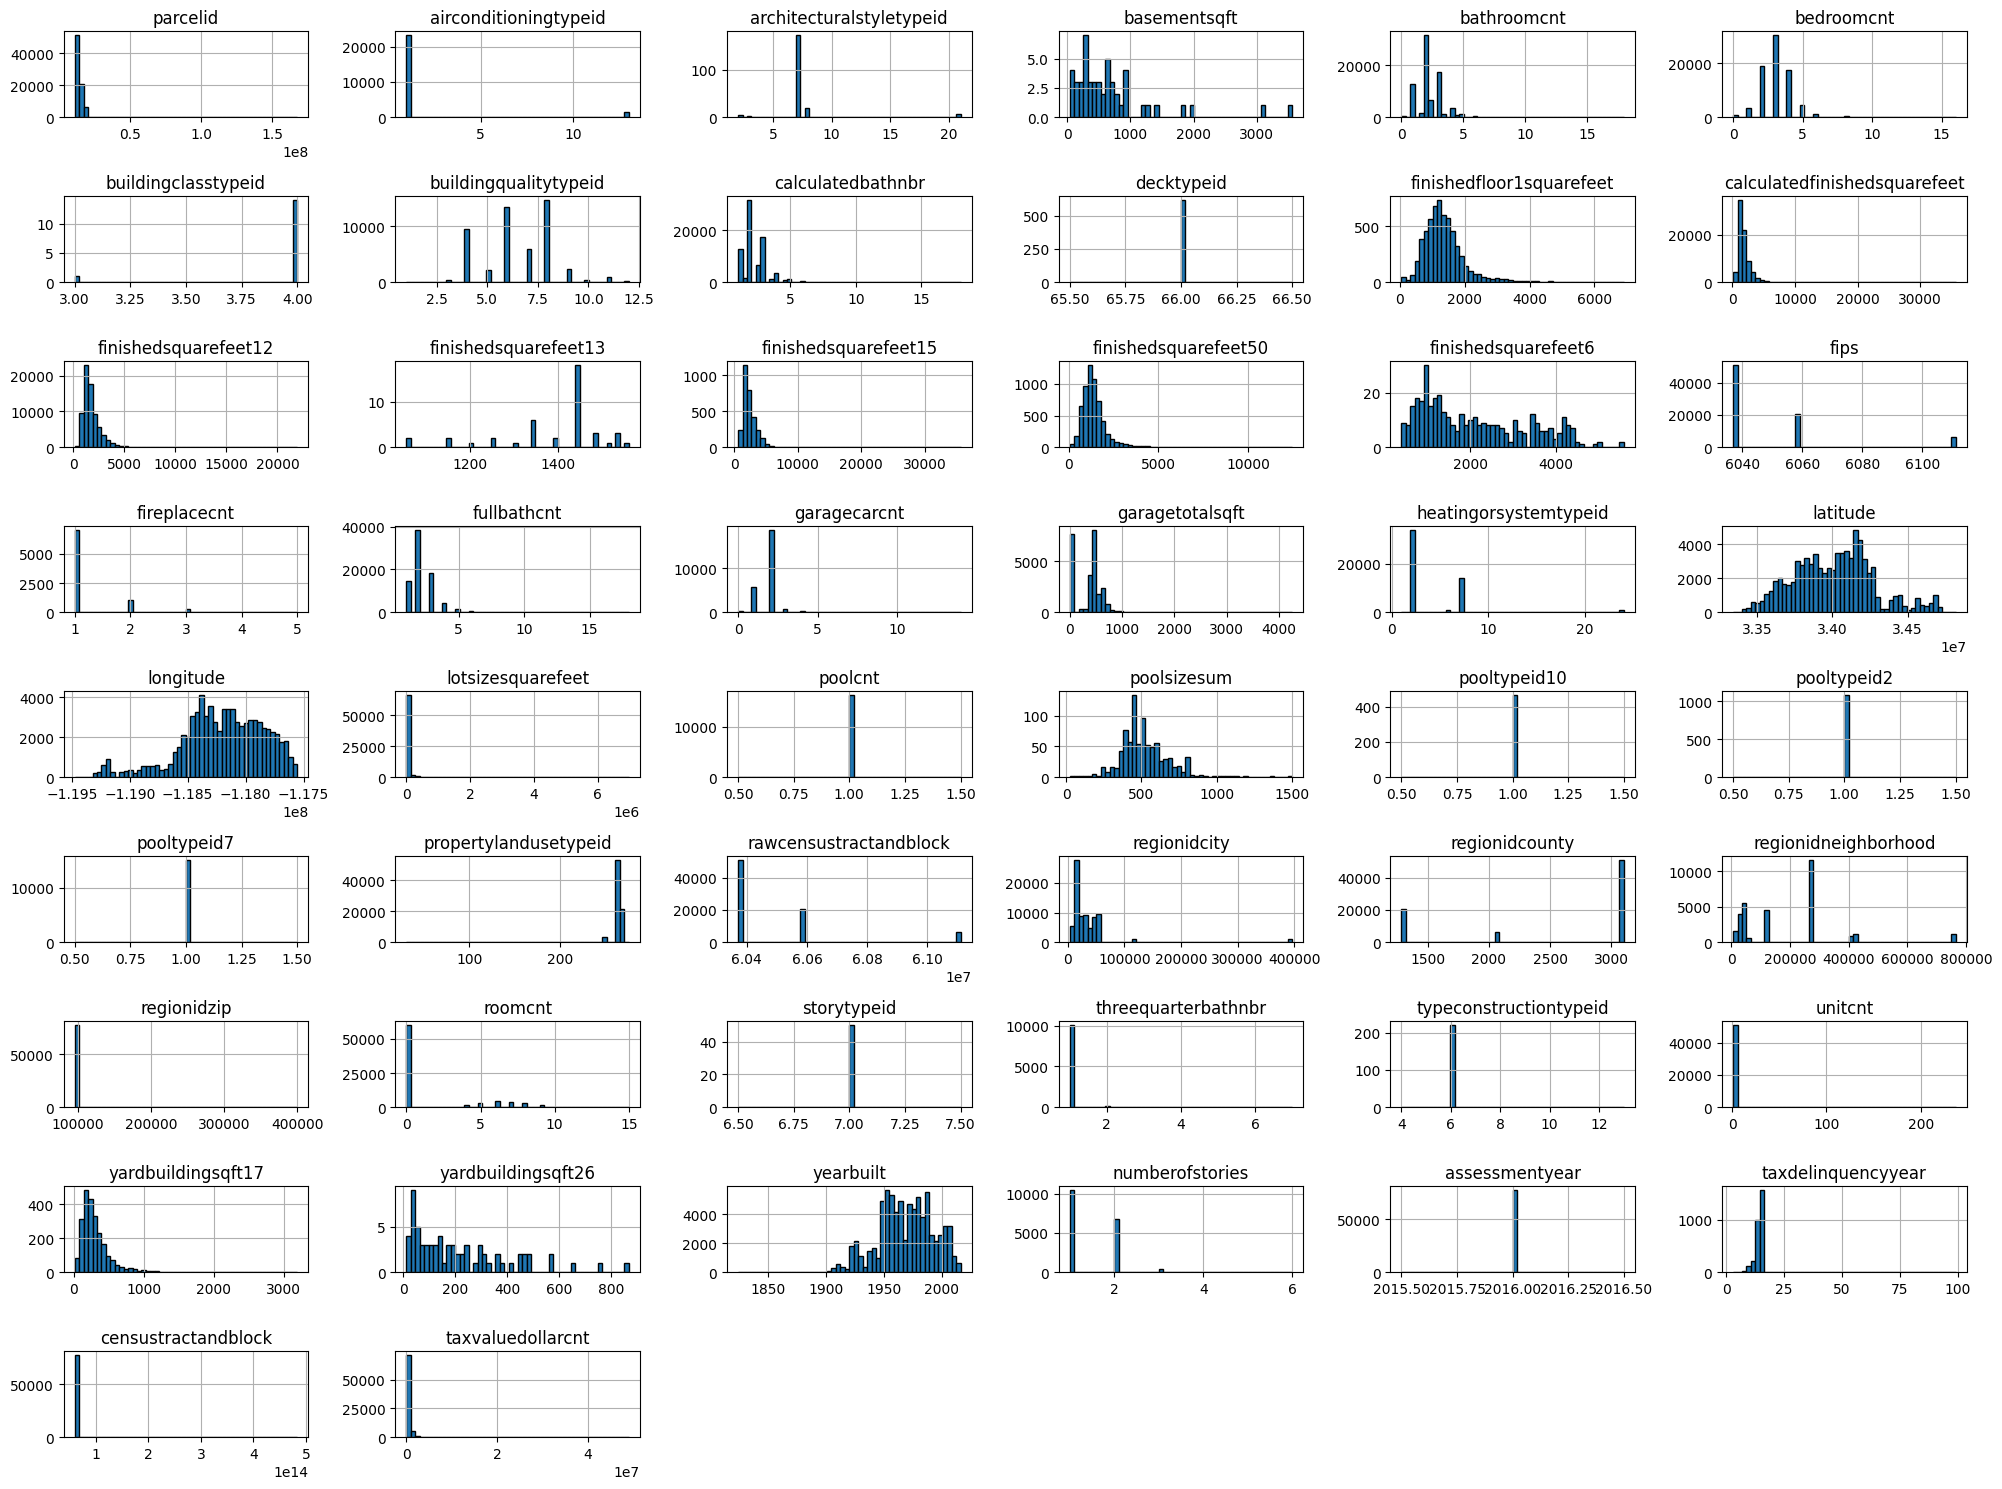

In [48]:
df.hist(figsize=(20, 15), layout=(-1, 6), bins=50, edgecolor='black')

plt.tight_layout()
plt.show()

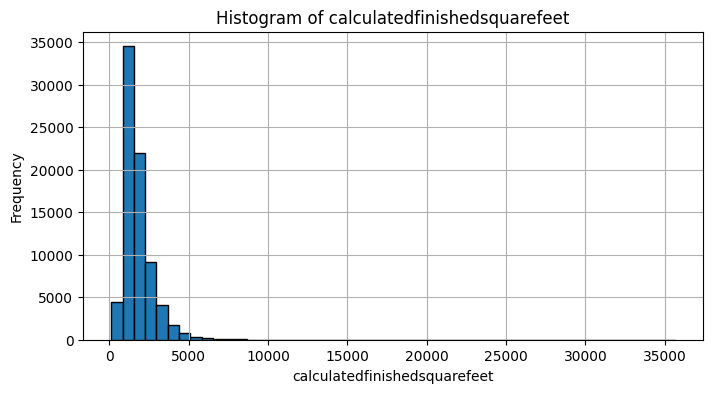

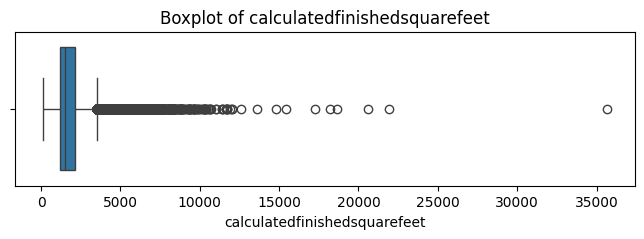

In [49]:
# Feature one: Calculated finished square feet
# This variable is interesting becasue it is likely to be correlated with property value and the histogram shows a decent amount 
# of spread that will hopefully capture meaningful variance in the target. 

# Specify variable and target
feature = 'calculatedfinishedsquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Here we have a right-skewed distribution with outliers well outside the upper IQR bound.
# Some outliers are very high, fairly spare, and should likely drive results. 

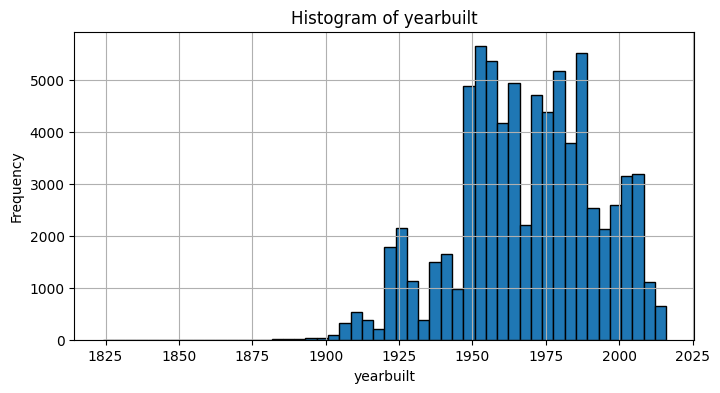

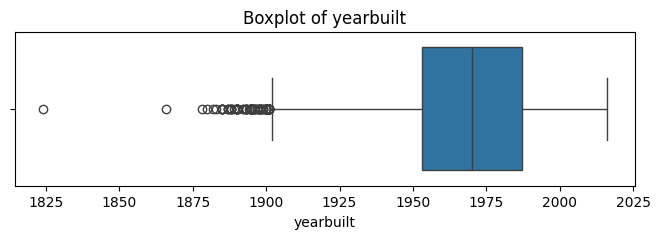

In [50]:
# Feature two: Year built
# This variable is interesting becasue it has a flatter and broader distribution than most others. It also isn't associated with inherent
# value but will indicate more about whether houses from a certain time period are more valuable than others. 

# Specify variable and target
feature = 'yearbuilt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Year built is a left-skewed distribution with a handful of early years built. There are a couple of outliers that would skew results in 
# analyses that consider the year built as a numeric variable, but in most use cases this should be categorical.

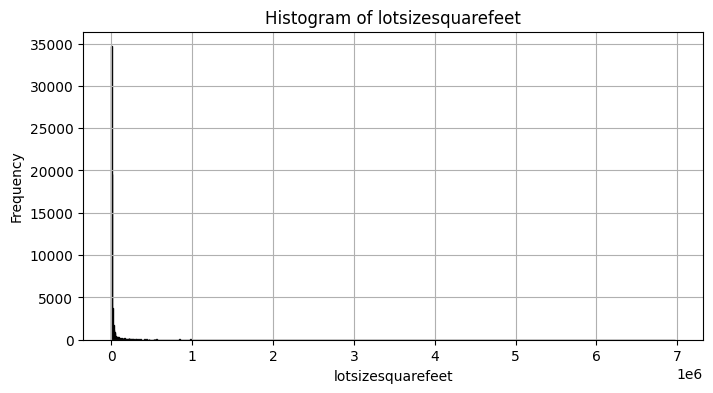

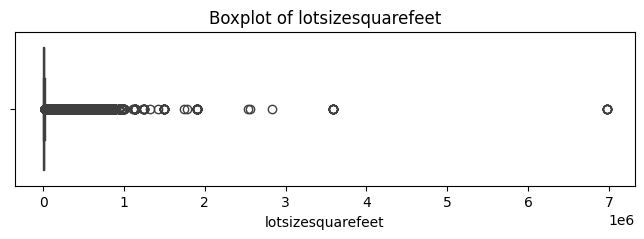

In [51]:
# Feature three: Lot size square feet
# Generally speaking, you pay more to have more so larger lot size is likely to be associated with higher value. It is also interesting
# in that most of the data falls within a narrow range. 

# Specify variable and target
feature = 'lotsizesquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=1000, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately 
# those above 1e6) that are sparse enough that they may drive/bias results depending on the analysis.

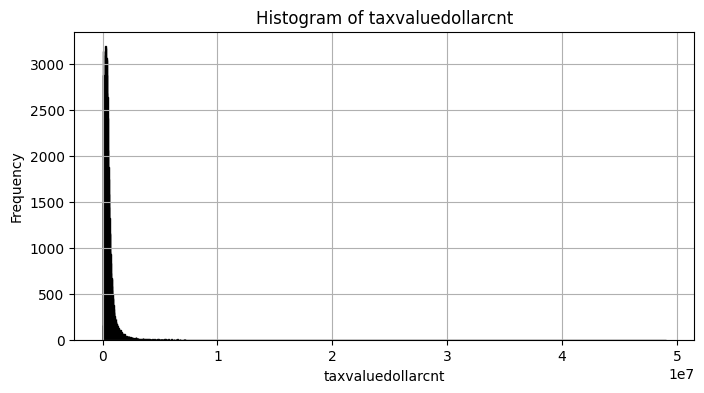

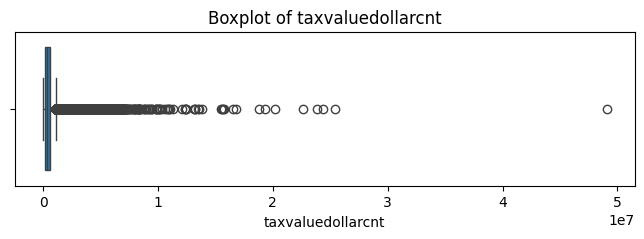

In [52]:
# Target: Tax value dollar cent

# Specify target
target = 'taxvaluedollarcnt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[target].dropna(), bins=2000, edgecolor='black')
plt.title(f'Histogram of {target}')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[target])
plt.title(f'Boxplot of {target}')
plt.show()

# The overall target distribution is most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very 
# narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems 
# reasonable as does the overall distribution. 

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [54]:
# Here we are dropping ID variables, text-based answers, latitude/longitude which are not useful without additional
# processing to integrate them, and categorical values unsuited for regression. 

df_clean = df.drop(columns=['airconditioningtypeid','regionidneighborhood','propertyzoningdesc',
                            'propertycountylandusecode','fips','rawcensustractandblock','censustractandblock', 
                            'latitude', 'longitude','regionidcity','regionidzip','regionidcounty',
                            'propertylandusetypeid','propertycountylandusecode','propertyzoningdesc','fireplaceflag',
                            'hashottuborspa','taxdelinquencyflag'])
df_clean.head()

,parcelid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,...,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,taxvaluedollarcnt
0,14297519,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,2016.0,NaN,1023282.0
1,17052889,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,...,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,2016.0,NaN,464000.0
2,14186244,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,2016.0,NaN,564778.0
3,12177905,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,2016.0,NaN,145143.0
4,10887214,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,2016.0,NaN,119407.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [55]:
# This function will list how many nulls occur in which features

def show_null_counts_features(df_clean):
    # Count the nulls and calculate the %
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)
    
    # Determine if the column is numeric or non-numeric
    feature_types = df.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')
    
    # Filter out the columns with missing values and sort them in descending order
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values, 
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)
    
    print(f'The dataset contains {len(df)} samples.\n')

    if (len(missing_data) == 0):
        print("There are no null values in the dataset!")
    else:
        # Print null value stats
        print('Feature Name    # Nulls      Null %    Type')
        print('------------    -------      ------    ----')
        for index, row in missing_data.iterrows():
            print(f"{row['Feature']:<15} {row['# Null Values']:<12} {row['Null %']:.2f}%   {row['Type']}")

show_null_counts_features(df_clean)

The dataset contains 77613 samples.

Feature Name    # Nulls      Null %    Type
------------    -------      ------    ----
buildingclasstypeid 77598        99.98%   Numeric
finishedsquarefeet13 77571        99.95%   Numeric
basementsqft    77563        99.94%   Numeric
storytypeid     77563        99.94%   Numeric
yardbuildingsqft26 77543        99.91%   Numeric
fireplaceflag   77441        99.78%   Categorical
architecturalstyletypeid 77406        99.73%   Numeric
typeconstructiontypeid 77390        99.71%   Numeric
finishedsquarefeet6 77227        99.50%   Numeric
pooltypeid10    77148        99.40%   Numeric
decktypeid      76999        99.21%   Numeric
poolsizesum     76744        98.88%   Numeric
pooltypeid2     76539        98.62%   Numeric
hashottuborspa  76074        98.02%   Categorical
yardbuildingsqft17 75220        96.92%   Numeric
taxdelinquencyflag 74713        96.26%   Categorical
taxdelinquencyyear 74713        96.26%   Numeric
finishedsquarefeet15 74586        96.10%

In [56]:
max_nulls = 0.2*len(df_clean)      
print(max_nulls)

15522.6


In [57]:
# The max_nulls limit here is currently set to 20%. Any variable with non-null values for less than 20% of instances will be dropped.
max_nulls = 0.2*len(df_clean)      # We will drop any features with more than max_nulls missing values

# Count null values per column

count_nulls = df_clean.isnull().sum()

# Filter out columns where null count exceeds max_nulls

filtered_df = df_clean.loc[:, df_clean.isnull().sum() <= max_nulls]

# Drop the columns

df_clean = df_clean.drop(columns=df_clean.columns[df_clean.isnull().sum() > max_nulls])

# Uncomment to verify they were removed

show_null_counts_features(df_clean)

The dataset contains 77613 samples.

Feature Name    # Nulls      Null %    Type
------------    -------      ------    ----
buildingclasstypeid 77598        99.98%   Numeric
finishedsquarefeet13 77571        99.95%   Numeric
basementsqft    77563        99.94%   Numeric
storytypeid     77563        99.94%   Numeric
yardbuildingsqft26 77543        99.91%   Numeric
fireplaceflag   77441        99.78%   Categorical
architecturalstyletypeid 77406        99.73%   Numeric
typeconstructiontypeid 77390        99.71%   Numeric
finishedsquarefeet6 77227        99.50%   Numeric
pooltypeid10    77148        99.40%   Numeric
decktypeid      76999        99.21%   Numeric
poolsizesum     76744        98.88%   Numeric
pooltypeid2     76539        98.62%   Numeric
hashottuborspa  76074        98.02%   Categorical
yardbuildingsqft17 75220        96.92%   Numeric
taxdelinquencyflag 74713        96.26%   Categorical
taxdelinquencyyear 74713        96.26%   Numeric
finishedsquarefeet15 74586        96.10%

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [58]:
# Instances missing a target value need to be dropped rather than imputed because we want to capture real variance in the data of the target
# rather than allow estimated outcome values to contribute to our results/conclusions. 

df_clean2 = df_clean.dropna(subset=['taxvaluedollarcnt'])

#show_null_counts_features(df_clean2)

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [59]:
# Identify categorical and numeric features
categorical_features = df_clean.select_dtypes(exclude=['number']).columns.tolist()
numeric_features     = df_clean.select_dtypes(include=['number']).columns.tolist()

# First make a copy of the cleaned dataset, call it df_imputed

df_imputed = df_clean2.copy()

# Impute numeric columns (using the median)

num_imputer = SimpleImputer(strategy='median')

# Verify: There should be no null values

df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

show_null_counts_features(df_imputed)

The dataset contains 77613 samples.

Feature Name    # Nulls      Null %    Type
------------    -------      ------    ----
buildingclasstypeid 77598        99.98%   Numeric
finishedsquarefeet13 77571        99.95%   Numeric
basementsqft    77563        99.94%   Numeric
storytypeid     77563        99.94%   Numeric
yardbuildingsqft26 77543        99.91%   Numeric
fireplaceflag   77441        99.78%   Categorical
architecturalstyletypeid 77406        99.73%   Numeric
typeconstructiontypeid 77390        99.71%   Numeric
finishedsquarefeet6 77227        99.50%   Numeric
pooltypeid10    77148        99.40%   Numeric
decktypeid      76999        99.21%   Numeric
poolsizesum     76744        98.88%   Numeric
pooltypeid2     76539        98.62%   Numeric
hashottuborspa  76074        98.02%   Categorical
yardbuildingsqft17 75220        96.92%   Numeric
taxdelinquencyflag 74713        96.26%   Categorical
taxdelinquencyyear 74713        96.26%   Numeric
finishedsquarefeet15 74586        96.10%

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [ ]:
# Impute categorical columns (using most frequent category)

cat_imputer = SimpleImputer(strategy='most_frequent')

# Verify: only numeric features should appear

df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

show_null_counts_features(df_imputed)

ValueError: at least one array or dtype is required

In [60]:
num_imputer = SimpleImputer(strategy='most_frequent')
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_features] = num_imputer.fit_transform(df[numeric_features])
print(df[numeric_features])

         parcelid  airconditioningtypeid  architecturalstyletypeid  \
0      14297519.0                    1.0                       7.0   
1      17052889.0                    1.0                       7.0   
2      14186244.0                    1.0                       7.0   
3      12177905.0                    1.0                       7.0   
4      10887214.0                    1.0                       7.0   
...           ...                    ...                       ...   
77608  10833991.0                    1.0                       7.0   
77609  11000655.0                    1.0                       7.0   
77610  17239384.0                    1.0                       7.0   
77611  12773139.0                    1.0                       7.0   
77612  12826780.0                    1.0                       7.0   

       basementsqft  bathroomcnt  bedroomcnt  buildingclasstypeid  \
0             100.0          3.5         4.0                  4.0   
1             100.0  

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

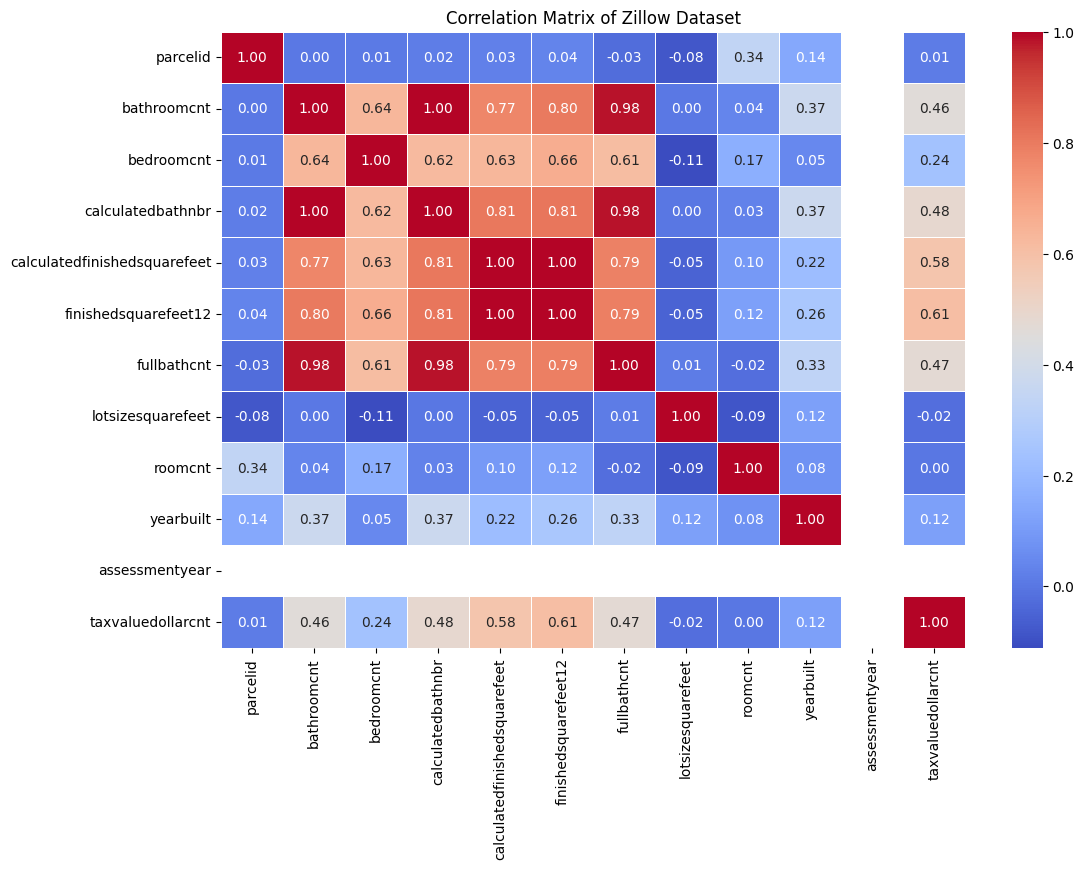

In [61]:
# Compute and analyze pairwise correlations using a correlation matrix.

correlation_matrix = df_clean.corr()  
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Zillow Dataset')
plt.show()

                         Feature  F-Statistic        P-Value
0                       parcelid     0.773046   1.000000e+00
1                    bathroomcnt     2.292154   0.000000e+00
2                     bedroomcnt     1.453867  2.754997e-205
3              calculatedbathnbr     2.292154   0.000000e+00
4   calculatedfinishedsquarefeet     4.346212   0.000000e+00
5           finishedsquarefeet12     4.346212   0.000000e+00
6                    fullbathcnt     2.159329   0.000000e+00
7              lotsizesquarefeet     0.669521   1.000000e+00
8                        roomcnt     1.908325   0.000000e+00
9                      yearbuilt     1.168434   2.084273e-38
10                assessmentyear          NaN            NaN


/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/tmp/ipykernel_6000/4068403207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')


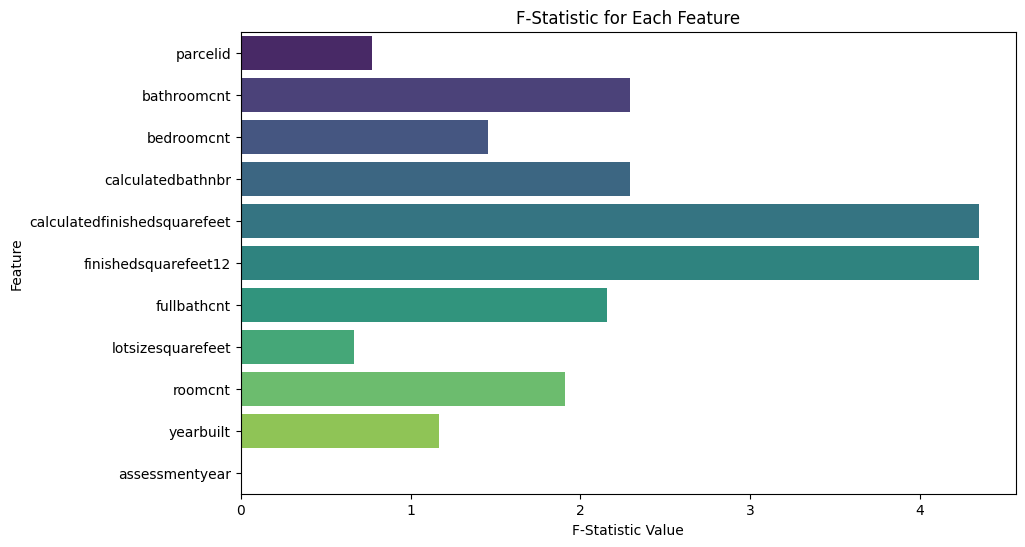

In [62]:
# Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).

from sklearn.feature_selection import f_classif
df_clean = df_clean.dropna()

X = df_clean.drop('taxvaluedollarcnt', axis=1)  
y = df_clean['taxvaluedollarcnt']


f_values, p_values = f_classif(X, y)

f_stat_df = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_values, 'P-Value': p_values})

print(f_stat_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')
plt.title('F-Statistic for Each Feature')
plt.xlabel('F-Statistic Value')
plt.ylabel('Feature')
plt.show()
 


In [63]:
# Investigate forward feature selection


from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_clean.drop('taxvaluedollarcnt', axis=1) 
y = df_clean['taxvaluedollarcnt']

model = LinearRegression()

selected_features = []
remaining_features = list(X.columns)

best_score = np.inf  

while remaining_features:
    scores = []
    
    for feature in remaining_features:
        features_to_test = selected_features + [feature]
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    scores.sort()
    
    best_score, best_feature = scores[0]
    
    selected_features.append(best_feature)
    
    remaining_features.remove(best_feature)

    print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")

print("Final selected features:", selected_features)


Selected Features: ['assessmentyear'] with Negative MSE: -426807974962.7332
Selected Features: ['assessmentyear', 'roomcnt'] with Negative MSE: -426782633270.4921
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid'] with Negative MSE: -426717186821.8734
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid', 'lotsizesquarefeet'] with Negative MSE: -426478602934.1483
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid', 'lotsizesquarefeet', 'yearbuilt'] with Negative MSE: -417499417689.2318
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid', 'lotsizesquarefeet', 'yearbuilt', 'bedroomcnt'] with Negative MSE: -387524776773.8204
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid', 'lotsizesquarefeet', 'yearbuilt', 'bedroomcnt', 'fullbathcnt'] with Negative MSE: -315689639642.2677
Selected Features: ['assessmentyear', 'roomcnt', 'parcelid', 'lotsizesquarefeet', 'yearbuilt', 'bedroomcnt', 'fullbathcnt', 'bathroomcnt'] with Negative MSE: -305984782231.5587

In [64]:
# Investigate backward feature selection

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_clean.drop('taxvaluedollarcnt', axis=1) 
y = df_clean['taxvaluedollarcnt']

model = LinearRegression()

selected_features = list(X.columns)
remaining_features = selected_features.copy()

best_score = np.inf  

while len(remaining_features) > 0:
    scores = []
    
    for feature in remaining_features:
        features_to_test = [f for f in selected_features if f != feature]
        
        if len(features_to_test) == 0:
            continue
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    if scores:
        scores.sort()
        best_score, worst_feature = scores[0]
        
        selected_features.remove(worst_feature)
        remaining_features.remove(worst_feature)

        print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")
    else:
        break

print("Final selected features:", selected_features)



Selected Features: ['parcelid', 'bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'lotsizesquarefeet', 'roomcnt', 'yearbuilt', 'assessmentyear'] with Negative MSE: -261830999916.4766
Selected Features: ['parcelid', 'bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'lotsizesquarefeet', 'roomcnt', 'assessmentyear'] with Negative MSE: -264037702680.1325
Selected Features: ['parcelid', 'bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'lotsizesquarefeet', 'assessmentyear'] with Negative MSE: -265531059658.2924
Selected Features: ['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'lotsizesquarefeet', 'assessmentyear'] with Negative MSE: -265863029310.3683
Selected Features: ['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', '

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

In the correlation matrix of the dataset, it became clear from the heat map that many of the features were strongly correlated with each other. For example, there is a 0.99 correlation between 'fullbathcnt' and 'calculatedbathbr', 0.81 correlation between 'calculatedbathbr' and 'calculatedfinishedsquarefeet', and a 0.79 correlation between 'calculatedfinishedsquarefeet' and 'fullbathcnt'.However, these specific correlations mentioned are not that insightful in reaching our goal, but they do confirm our method is working properly. For instance, 'fullbathcnt' is a count of the full bathrooms in a house and 'calculatedbathbr'is the calculated number of bathrooms, including fractional bathrooms in the house. Although some houses may only have a 1/2 bathroom, a majority will have at least 1 full so it makes sense that as the count of full bathrooms increases (or decreases), the total count of bathrooms in the house will as well. A similar approach can be seen between 'calculatedbathbr' and 'calculatedfinishedsquarefeet'. It is fair to assume that a house that is larger (i.e. has more square feet) will have more space and potential need for a greater number of bathrooms which can explain a large positive correlation between the two features. It was particularly interesting to look at our target variable, 'taxvaluedollarcnt', and its correlation to various features in the dataset. The highest correlations came at 0.61 between the target and 'calculatedfinishedsquarefeet'. This is indicates that there is a moderate correlation between the two and potentially a important feature in predicting taxvaluedollarcnt. The next highest correlation was 0.51 between the target and 'calculatedbathnbr'; this relationship needs further exploration to determine if the correlation is impactful in our predictions.

The F-statistic and p-value calculations further enforced the relationships seen in the correlation matrix. The two highest correlations among the target, 'calculatedfinishedsquarefeet' and 'calculatedbathnbr', each were found to be significantly significant. For 'calculatedfinishedsquarefeet', there was an F-statistic = 4.346212 and P-value = 0.000000e+00 and 'calculatedbathnbr' had a F-statistic = 2.292154 and P-value = 0.000000e+00. These results also reinforced that some of the lower correlations among the target value were indeed insignificant. For example, 'lotsizesquarefeet' had a -0.02 correlation with the target and an F-statistic = 0.669521 and P-value = 1.000000e+00; this suggests no significant impact on the outcome and can be eliminated from our feature list. What was interesting was that 'roomcnt' and 'yearbuilt' which both had no low correlations, 0.00 and 0.12, respectively, were found to be highly significant. 'Roomcnt' had a 0.00 F-statistic = 1.908325 and P-value = 0.000000e+00 and 'yearbuilt' an F-statistic = 1.168434 and P-value = 2.084273e-3. This tells us that the relationship between these features and the target are not linear, however they are impacting the model and are necessary for our analysis.

Lastly, the forward and backward selection did not provide as much useful insight. The MSE scores were extremely large and although some of the chosen features in the forward selection matched the significant and highly correlated ones we saw above, there is still some uncertainity surrounding their impact on our model.


### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

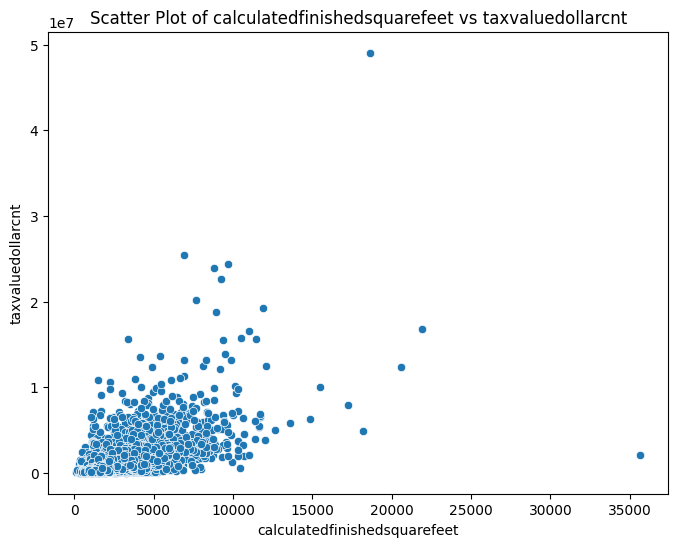

In [77]:
# Pair 1: "taxvaluedollarcnt" vs "calculatedfinishedsquarefeet"
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='calculatedfinishedsquarefeet', y='taxvaluedollarcnt')
plt.title("Scatter Plot of calculatedfinishedsquarefeet vs taxvaluedollarcnt")
plt.xlabel('calculatedfinishedsquarefeet')
plt.ylabel('taxvaluedollarcnt')
plt.show()


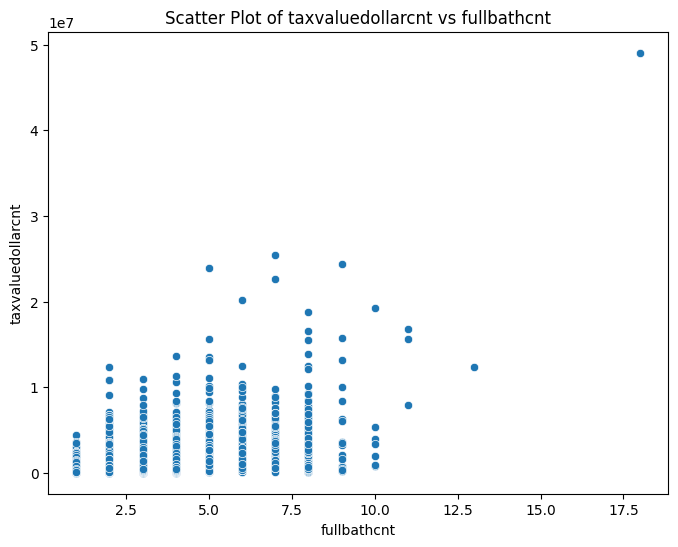

In [82]:
# Pair 2: "fullbathcnt" vs "taxvaluedollarcnt" 
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='fullbathcnt', y='taxvaluedollarcnt')
plt.title("Scatter Plot of taxvaluedollarcnt vs fullbathcnt")
plt.xlabel('fullbathcnt')
plt.ylabel('taxvaluedollarcnt')
plt.show()

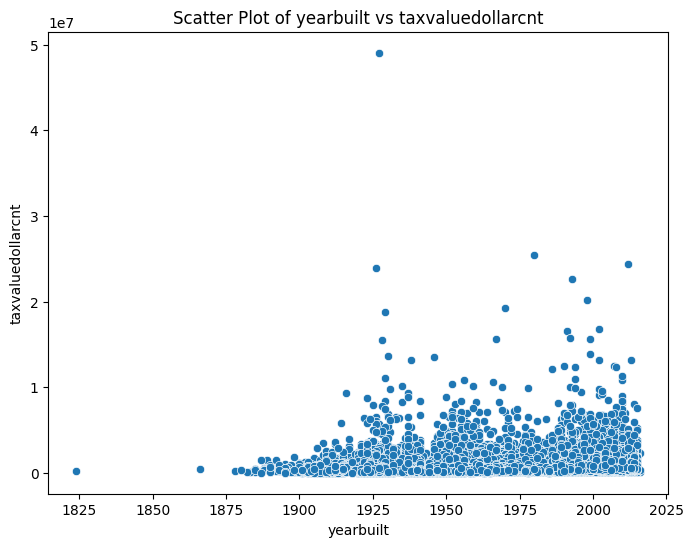

In [79]:
# Pair 3: "taxvaluedollarcnt" vs "yearbuilt" 
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='yearbuilt', y='taxvaluedollarcnt')
plt.title("Scatter Plot of yearbuilt vs taxvaluedollarcnt")
plt.xlabel('yearbuilt')
plt.ylabel('taxvaluedollarcnt')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The three scatterplots picked were relationships that had been identified in previous analysis as either highly correlated or being highly significant according to the F-Statistic and p-values. The first plot, "taxvaluedollarcnt" vs "calculatedfinishedsquarefeet" produced a graph that had points heavily focused between 0-10,000 on the x axis and 0-1 on the y axis. There is a relationship that can be seen in the graph; as the x value increases, so does the y, indictating a correlation between these two features as previously believed. The graph did help us identify that there are a few outliers in this relationship to be aware of as seen by the data point at about (36,000, 0.2) and (19,000, 4.8). In the second plot, "taxvaluedollarcnt" vs "fullbathcnt", a relationship that has been identified as having a moderate to high correlation and being highly significant. This graph produced vertical lines on the graph, with a majority of the values falling between 0 and 10 on the x axis and 0 to 1 on the y axis. The graph follows a bit of biomodial distruption and there are a few outliers, one being very large, at about (17.5, 5). The vertical lines on this graph make sense because the amount of bathrooms in house must fall on 0.5 increment. In other words, there will not be a 1.7 or 2.8 amount of bathrooms in a house. As a result, the graph is going to show minimal variance on the x-axis. The last graph displays the relationship between "taxvaluedollarcnt" vs "yearbuilt". This relationship had no correlation, however it was highly significant according to its F-Statistic and p-value. This graph is fairly interesting with most of the data clustered to be under 1 on the y axis with a few outliers (one large on at 1952 and 4.8). There is a bit of an increase in the average of the taxvaluedollarcnt from about 1980 to 2017 which makes sense as inflation rates rise and the housing market trends has significant changes in this time period. As predicted, there is no clear correlation between these two features, however the graph does provide insight into how the taxvaluedollarcnt trends have changed through the years (as seen by how the data clusters/groups together).


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [70]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


In [71]:
# Apply log transformation to the features 
X_log = np.log1p(X)  

In [72]:
# Create Polynomial Features 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Convert to DataFrame (to inspect new features)
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X.columns))


In [73]:
selector = SelectKBest(score_func=f_classif, k='all')

# Evaluate F-scores for each transformation
selector.fit(X_scaled, y)
print("F-scores for Standardized Features:")
print(selector.scores_)

selector.fit(X_log, y)
print("\nF-scores for Log-transformed Features:")
print(selector.scores_)

selector.fit(X_poly, y)
print("\nF-scores for Polynomial Features:")
print(selector.scores_)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


F-scores for Standardized Features:
[0.77304582 2.2921538  1.45386736 2.2921538  4.34621225 4.34621225
 2.15932898 0.66952104 1.90832549 1.16843391        nan]


/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw



F-scores for Log-transformed Features:
[1.44087217 1.75441295 1.22467903 1.75441295 2.64046165 2.64046165
 1.67427727 0.89788863 1.8319547  1.16843382        inf]

F-scores for Polynomial Features:
[ 0.77304582  2.2921538   1.45386736  2.2921538   4.34621225  4.34621225
  2.15932898  0.66952104  1.90832549  1.16843391         nan  0.29448038
  1.72796094  1.32879731  1.72796094  3.38040239  3.38040239  1.63997054
  0.68142981  1.68813245  0.78288478  0.77304582  3.76588708  2.7856769
  3.76588708  6.92503705  6.92503705  3.65814747  0.79150175  2.18682438
  2.26820024  2.2921538   1.72947623  2.7856769   4.13087045  4.13087045
  2.67949853  0.72346877  1.99149368  1.45839198  1.45386736  3.76588708
  6.92503705  6.92503705  3.65814747  0.79150175  2.18682438  2.26820024
  2.2921538  10.61011451 10.61011451  6.78934109  0.94748944  2.49215042
  4.29865249  4.34621225 10.61011451  6.78934109  0.94748944  2.49215042
  4.29865249  4.34621225  3.54499947  0.78704687  2.18010637  2.13761452

/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [10 76] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [74]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Evaluate using cross-validation (default scoring is R^2 for regression)
cv_score_standardized = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
cv_score_log = cross_val_score(model, X_log, y, cv=5, scoring='neg_mean_squared_error')
cv_score_poly = cross_val_score(model, X_poly, y, cv=5, scoring='neg_mean_squared_error')

print("\nCross-Validation MSE for Standardized Data: ", -cv_score_standardized.mean())
print("Cross-Validation MSE for Log-Transformed Data: ", -cv_score_log.mean())
print("Cross-Validation MSE for Polynomial Features: ", -cv_score_poly.mean())



Cross-Validation MSE for Standardized Data:  250593936779.26398
Cross-Validation MSE for Log-Transformed Data:  306426511164.1134
Cross-Validation MSE for Polynomial Features:  238543917849.7906


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

